In [1]:
import netCDF4 as nc
import numpy as np
import xarray as xr
import warnings
from eofs.xarray import Eof
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import gridspec
import datetime
import seaborn as sns
import cmocean as cmo
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from scipy.stats import linregress
from proj_utils import *
from mapping_utils import *
import matplotlib.patches as mpatches
import scipy.io as sio
import matplotlib.colors as mcolors

In [2]:
data_path = '/Users/lillienders/Documents/gs_var/data/'
fig_path  = '/Users/lillienders/Documents/gs_var/figures/'

### Load SLP

In [3]:
slp_da = xr.open_dataset(data_path + 'era_downloads/north_atlantic_slp.nc')
slp_da = slp_da.sel(expver = slice(0,1))
slp_da = slp_da.squeeze()
slp_da = slp_da.drop_vars('expver')
slp_da = slp_da.sel(time = slice('1993-01-01','2023-12-01'))
slp_da = slp_da.sortby(slp_da.latitude)

In [4]:
slp_da = rmv_clm(slp_da)
slp_da = seasonal_detrend(slp_da)

### Load NAO

In [5]:
eofs_full, pcs_full, per_var_full, eigs_full = calc_eofs(slp_da['msl'], num_modes=4)

/Users/lillienders/Documents/gs_var/proj_utils.py:319: RuntimeWarning: invalid value encountered in sqrt
  wgts = np.sqrt(coslat)[..., np.newaxis]


In [6]:
pcs_unscaled = pcs_full*np.sqrt(eigs_full[:4])

In [7]:
nao_uf = -pcs_full[:,0]
nao_f = lanczos_bandpass(nao_uf, low_freq = 12*6, high_freq = 12*11, window = 12) 
nao_f = (nao_f - nao_f.mean(dim='time'))/nao_f.std(dim = 'time')

In [8]:
nao_unscaled = -pcs_unscaled[:,0]

### Load GSI 

In [9]:
gsi_uf  = xr.open_dataarray(data_path + 'gsi/alt_gsi_24.nc')
gsi_f = lanczos_bandpass(gsi_uf, low_freq = 12*6, high_freq = 12*11, window = 12) 
gsi_f['time'] = nao_f.time
gsi_f = (gsi_f - gsi_f.mean(dim = 'time'))/gsi_f.std(dim = 'time')
gsi_f = gsi_f[~np.isnan(gsi_f)]

### Misc Params

In [10]:
n_lags = 12*1
lags_array = np.arange(-12,13)

### Case One: 1996-06 to 2000-06

In [11]:
slp_case = slp_da.sel(time = slice(np.datetime64(str(1996) + '-06-01'),np.datetime64(str(2000) + '-06-01')))
gsi_case = gsi_f.sel(time = slice(np.datetime64(str(1996) + '-06-01'),np.datetime64(str(2000) + '-06-01')))
nao_case = nao_f.sel(time = slice(np.datetime64(str(1996) + '-06-01'),np.datetime64(str(2000) + '-06-01')))

eofs_case, pcs_case, per_var_case, _ = calc_eofs(slp_case['msl'], num_modes=4)

/Users/lillienders/Documents/gs_var/proj_utils.py:319: RuntimeWarning: invalid value encountered in sqrt
  wgts = np.sqrt(coslat)[..., np.newaxis]


In [12]:
corrs_case = lagged_corr(nao_case, gsi_case, n_lags) # Calculate Lagged Correlations
corrs_case = np.array(corrs_case)                    # Convert to array
lci,uci    = get_cis(nao_case, gsi_case,n_lags)      # Calculate confidence intervals

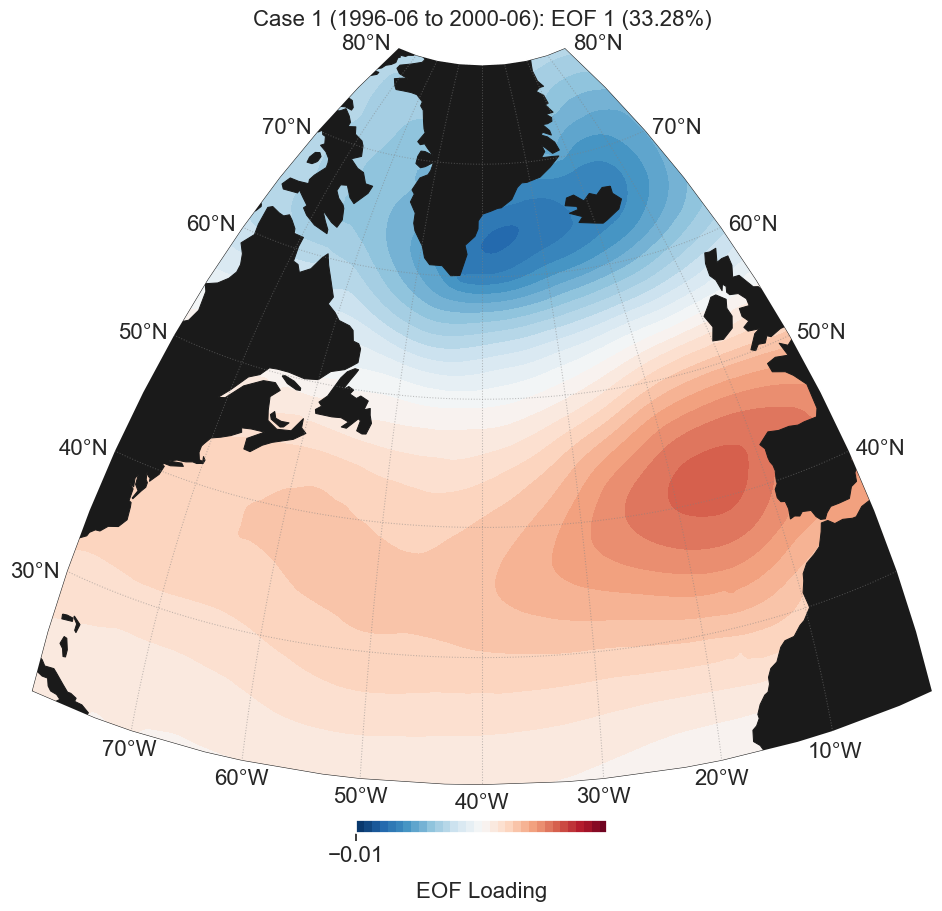

In [13]:
save_name    = 'case_one_eof_one'
slp_eof      = -eofs_case[0,:,:]
eof_pve      = per_var_case[0]
slp_eof.data[slp_eof.data > 0.01] = 0.01
slp_eof.data[slp_eof.data < -0.01] = -0.01

bbox          = [-80,0,20,80] # Plotting Extent
plot_this_box = [-80,0,0,60]    # Locator box indicating a region
proj          = ccrs.PlateCarree() # Need to add this to most things as "transform=proj"
fig,ax,_      = init_orthomap(1,1,bbox)


# Add Coasts/Continent
ax     = add_coast_grid(ax,bbox,fill_color='k',line_color='k')
levels = np.linspace(-0.01,0.01,33)
# Plot contours
colorplot = ax.contourf(slp_eof.longitude,slp_eof.latitude,slp_eof.data,transform=proj, levels=levels, cmap='RdBu_r', zorder=0)
cbar = plt.colorbar(colorplot, fraction=0.017, pad=0.01, orientation='horizontal',ticks=np.linspace(-0.01, 0.01, 1))
cbar.set_label('EOF Loading', size='16', labelpad=11)
plt.title('Case 1 (' + str(slp_case.time[0].dt.year.data) + '-' + str(slp_case.time[0].dt.month.data).zfill(2) +  ' to ' + str(slp_case.time[-1].dt.year.data) + '-' + str(slp_case.time[-1].dt.month.data).zfill(2) +'): EOF 1 (' + str('{:.2f}'.format(eof_pve*100)) + '%)', fontsize = 16)

cbar.ax.tick_params(labelsize=16)
plt.savefig(fig_path  + save_name + '.png', format='png', bbox_inches="tight",dpi=100)

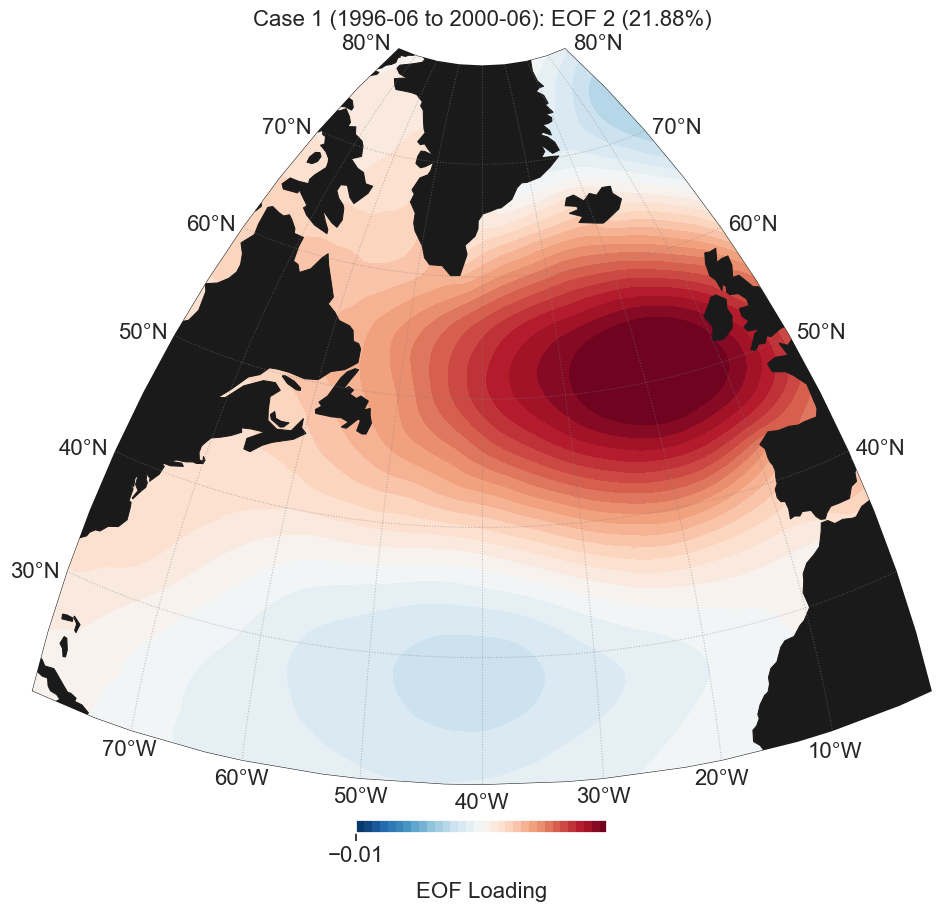

In [233]:
save_name    = 'case_one_eof_two'
slp_eof      = eofs_case[1,:,:]
eof_pve      = per_var_case[1]
slp_eof.data[slp_eof.data > 0.01] = 0.01
slp_eof.data[slp_eof.data < -0.01] = -0.01

bbox          = [-80,0,20,80] # Plotting Extent
plot_this_box = [-80,0,0,60]    # Locator box indicating a region
proj          = ccrs.PlateCarree() # Need to add this to most things as "transform=proj"
fig,ax,_      = init_orthomap(1,1,bbox)


# Add Coasts/Continent
ax     = add_coast_grid(ax,bbox,fill_color='k',line_color='k')
levels = np.linspace(-0.01,0.01,33)
# Plot contours
colorplot = ax.contourf(slp_eof.longitude,slp_eof.latitude,slp_eof.data,transform=proj, levels=levels, cmap='RdBu_r', zorder=0)
cbar = plt.colorbar(colorplot, fraction=0.017, pad=0.01, orientation='horizontal',ticks=np.linspace(-0.01, 0.01, 1))
cbar.set_label('EOF Loading', size='16', labelpad=11)
plt.title('Case 1 (' + str(slp_case.time[0].dt.year.data) + '-' + str(slp_case.time[0].dt.month.data).zfill(2) +  ' to ' + str(slp_case.time[-1].dt.year.data) + '-' + str(slp_case.time[-1].dt.month.data).zfill(2) +'): EOF 2 (' + str('{:.2f}'.format(eof_pve*100)) + '%)', fontsize = 16)

cbar.ax.tick_params(labelsize=16)
plt.savefig(fig_path  + save_name + '.png', format='png', bbox_inches="tight",dpi=100)

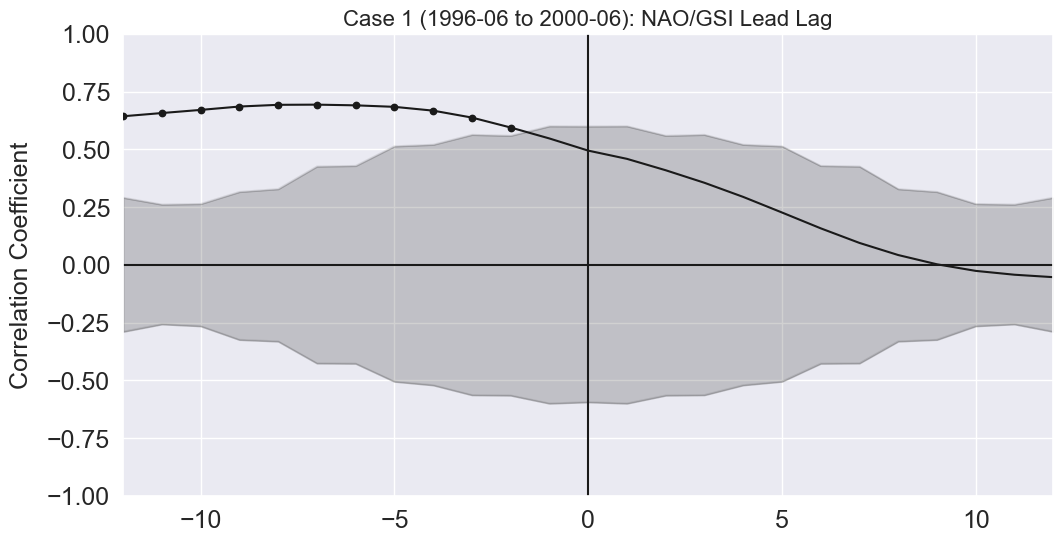

In [234]:
save_name    = 'case_one_lead_lag'
ix_temp = []
for l in range(len(corrs_case)):
    if corrs_case[l] > uci[l] or corrs_case[l] < lci[l]:
        ix_temp.append(l)

fig     = plt.figure(figsize=(12, 6))
plt.title('Case 1 (' + str(slp_case.time[0].dt.year.data) + '-' + str(slp_case.time[0].dt.month.data).zfill(2) +  ' to ' + str(slp_case.time[-1].dt.year.data) + '-' + str(slp_case.time[-1].dt.month.data).zfill(2) +'): NAO/GSI Lead Lag', fontsize = 16)
        
# Bottom Figure is Lead/Lag for that period 
plt.axhline(0,color='k')
plt.axvline(0,color='k')
plt.plot(lags_array,corrs_case,'k')
lci_  = plt.plot(lags_array,lci, color='k',alpha=0.1)
uci_  = plt.plot(lags_array,uci, color='k',alpha=0.1)
ci_sh = plt.fill_between(lags_array,lci,uci,color='k',alpha=0.2)
plt.scatter(lags_array[ix_temp], corrs_case[ix_temp], s=21, color = 'k',edgecolors='k',zorder = 10)
xtix = plt.yticks(fontsize=18)
xtix = plt.xticks(fontsize=18)
ylab = plt.ylabel('Correlation Coefficient', fontsize = 18, labelpad=10)
plt.ylim(-1,1)
plt.xlim(-12,12)
plt.savefig(fig_path  + save_name + '.png', format='png', bbox_inches="tight",dpi=100)

### Case Two: 2005 to 2009

In [235]:
slp_case = slp_da.sel(time = slice(np.datetime64(str(2005) + '-06-01'),np.datetime64(str(2009) + '-06-01')))
gsi_case = gsi_f.sel(time = slice(np.datetime64(str(2005) + '-06-01'),np.datetime64(str(2009) + '-06-01')))
nao_case = nao_f.sel(time = slice(np.datetime64(str(2005) + '-06-01'),np.datetime64(str(2009) + '-06-01')))

eofs_case, pcs_case, per_var_case, _ = calc_eofs(slp_case['msl'], num_modes=4)

/Users/lillienders/Documents/gs_var/proj_utils.py:319: RuntimeWarning: invalid value encountered in sqrt
  wgts = np.sqrt(coslat)[..., np.newaxis]


In [236]:
corrs_case = lagged_corr(nao_case, gsi_case, n_lags) # Calculate Lagged Correlations
corrs_case = np.array(corrs_case)                    # Convert to array
lci,uci    = get_cis(nao_case, gsi_case,n_lags)      # Calculate confidence intervals

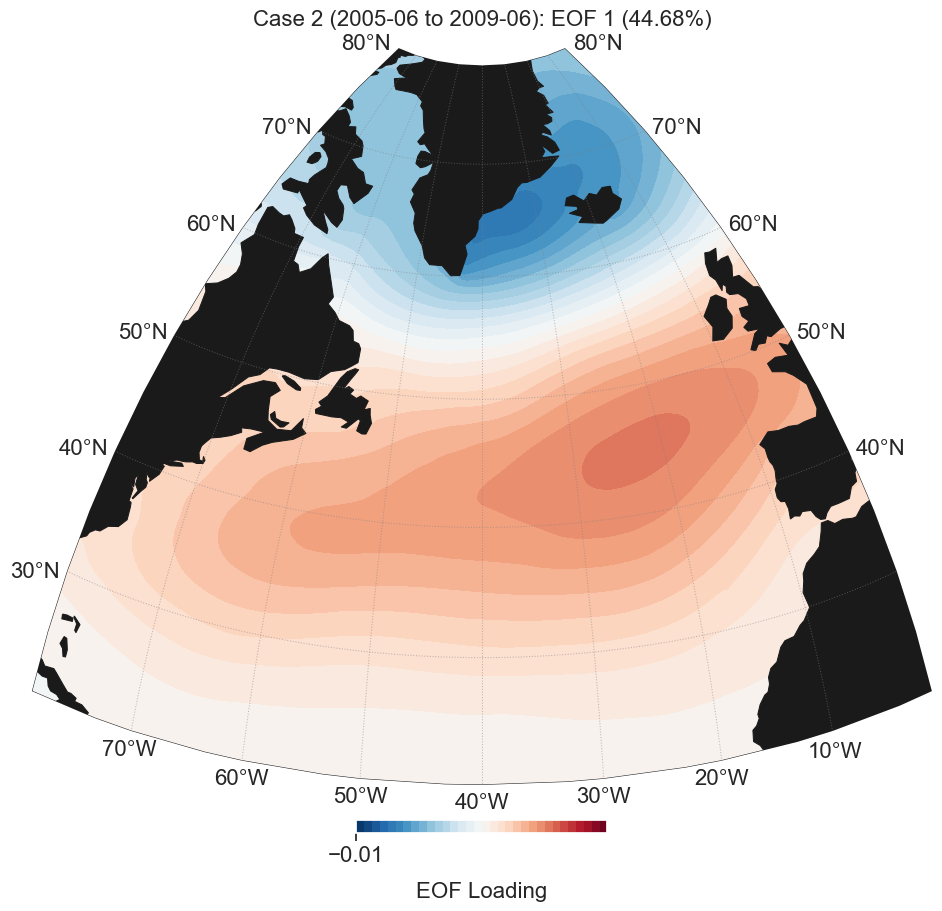

In [237]:
save_name    = 'case_two_eof_one'
slp_eof      = eofs_case[0,:,:]
eof_pve      = per_var_case[0]
slp_eof.data[slp_eof.data > 0.01] = 0.01
slp_eof.data[slp_eof.data < -0.01] = -0.01

bbox          = [-80,0,20,80] # Plotting Extent
plot_this_box = [-80,0,0,60]    # Locator box indicating a region
proj          = ccrs.PlateCarree() # Need to add this to most things as "transform=proj"
fig,ax,_      = init_orthomap(1,1,bbox)


# Add Coasts/Continent
ax     = add_coast_grid(ax,bbox,fill_color='k',line_color='k')
levels = np.linspace(-0.01,0.01,33)
# Plot contours
colorplot = ax.contourf(slp_eof.longitude,slp_eof.latitude,slp_eof.data,transform=proj, levels=levels, cmap='RdBu_r', zorder=0)
cbar = plt.colorbar(colorplot, fraction=0.017, pad=0.01, orientation='horizontal',ticks=np.linspace(-0.01, 0.01, 1))
cbar.set_label('EOF Loading', size='16', labelpad=11)
plt.title('Case 2 (' + str(slp_case.time[0].dt.year.data) + '-' + str(slp_case.time[0].dt.month.data).zfill(2) +  ' to ' + str(slp_case.time[-1].dt.year.data) + '-' + str(slp_case.time[-1].dt.month.data).zfill(2) +'): EOF 1 (' + str('{:.2f}'.format(eof_pve*100)) + '%)', fontsize = 16)

cbar.ax.tick_params(labelsize=16)
plt.savefig(fig_path  + save_name + '.png', format='png', bbox_inches="tight",dpi=100)

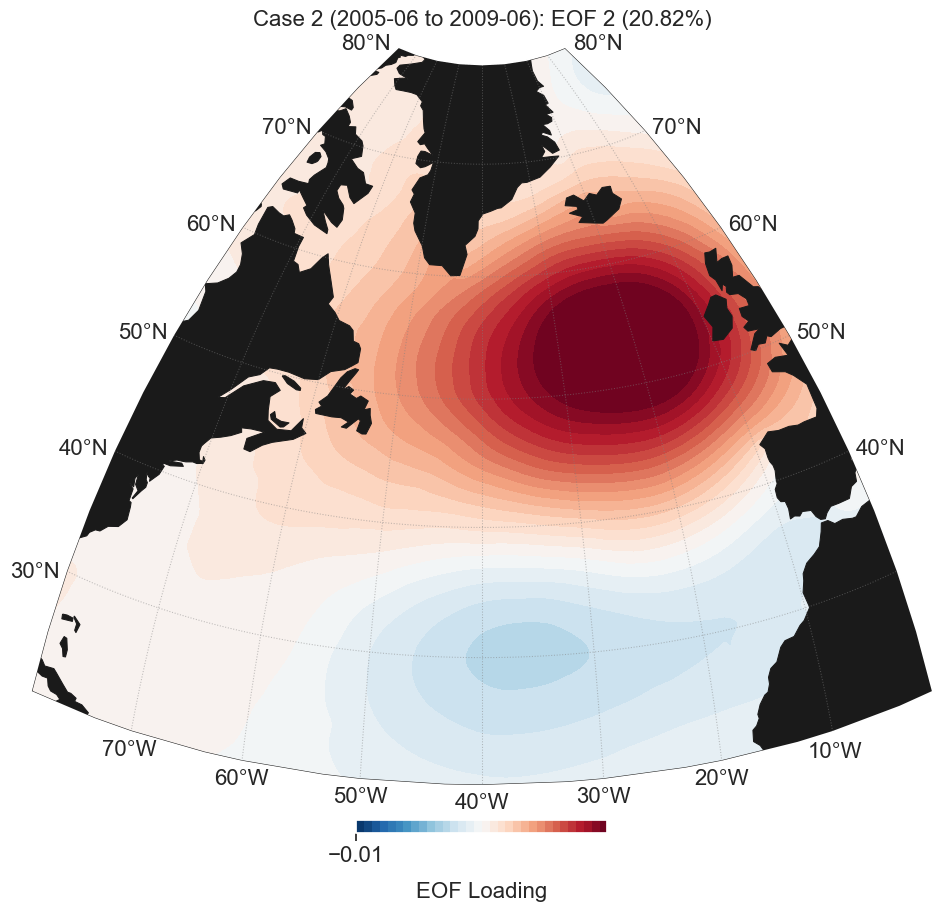

In [238]:
save_name    = 'case_two_eof_two'
slp_eof      = eofs_case[1,:,:]
eof_pve      = per_var_case[1]
slp_eof.data[slp_eof.data > 0.01] = 0.01
slp_eof.data[slp_eof.data < -0.01] = -0.01

bbox          = [-80,0,20,80] # Plotting Extent
plot_this_box = [-80,0,0,60]    # Locator box indicating a region
proj          = ccrs.PlateCarree() # Need to add this to most things as "transform=proj"
fig,ax,_      = init_orthomap(1,1,bbox)


# Add Coasts/Continent
ax     = add_coast_grid(ax,bbox,fill_color='k',line_color='k')
levels = np.linspace(-0.01,0.01,33)
# Plot contours
colorplot = ax.contourf(slp_eof.longitude,slp_eof.latitude,slp_eof.data,transform=proj, levels=levels, cmap='RdBu_r', zorder=0)
cbar = plt.colorbar(colorplot, fraction=0.017, pad=0.01, orientation='horizontal',ticks=np.linspace(-0.01, 0.01, 1))
cbar.set_label('EOF Loading', size='16', labelpad=11)
plt.title('Case 2 (' + str(slp_case.time[0].dt.year.data) + '-' + str(slp_case.time[0].dt.month.data).zfill(2) +  ' to ' + str(slp_case.time[-1].dt.year.data) + '-' + str(slp_case.time[-1].dt.month.data).zfill(2) +'): EOF 2 (' + str('{:.2f}'.format(eof_pve*100)) + '%)', fontsize = 16)

cbar.ax.tick_params(labelsize=16)
plt.savefig(fig_path  + save_name + '.png', format='png', bbox_inches="tight",dpi=100)

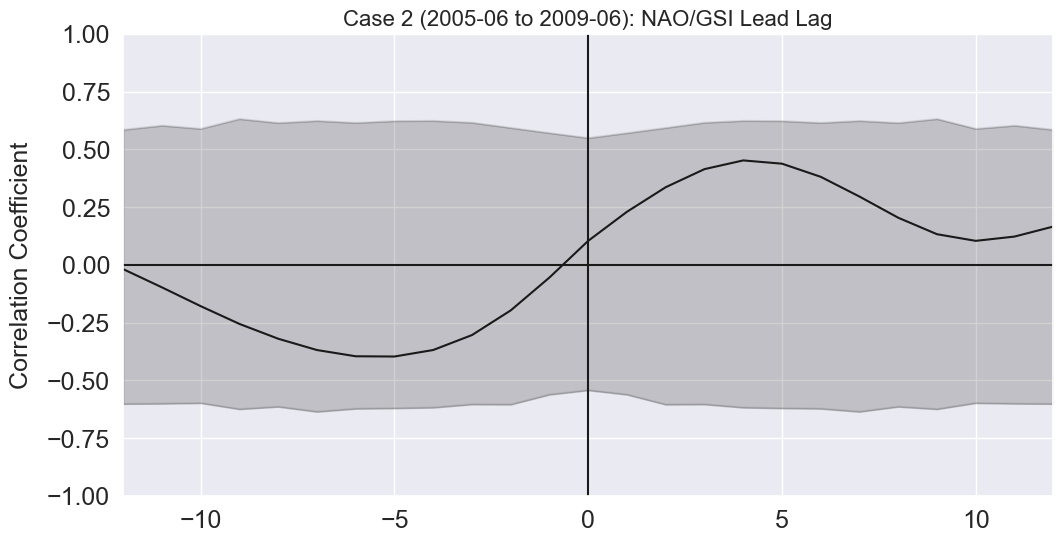

In [239]:
save_name    = 'case_two_lead_lag'
ix_temp = []
for l in range(len(corrs_case)):
    if corrs_case[l] > uci[l] or corrs_case[l] < lci[l]:
        ix_temp.append(l)

fig     = plt.figure(figsize=(12, 6))
plt.title('Case 2 (' + str(slp_case.time[0].dt.year.data) + '-' + str(slp_case.time[0].dt.month.data).zfill(2) +  ' to ' + str(slp_case.time[-1].dt.year.data) + '-' + str(slp_case.time[-1].dt.month.data).zfill(2) +'): NAO/GSI Lead Lag', fontsize = 16)
        
# Bottom Figure is Lead/Lag for that period 
plt.axhline(0,color='k')
plt.axvline(0,color='k')
plt.plot(lags_array,corrs_case,'k')
lci_  = plt.plot(lags_array,lci, color='k',alpha=0.1)
uci_  = plt.plot(lags_array,uci, color='k',alpha=0.1)
ci_sh = plt.fill_between(lags_array,lci,uci,color='k',alpha=0.2)
plt.scatter(lags_array[ix_temp], corrs_case[ix_temp], s=21, color = 'k',edgecolors='k',zorder = 10)
xtix = plt.yticks(fontsize=18)
xtix = plt.xticks(fontsize=18)
ylab = plt.ylabel('Correlation Coefficient', fontsize = 18, labelpad=10)
plt.ylim(-1,1)
plt.xlim(-12,12)
plt.savefig(fig_path  + save_name + '.png', format='png', bbox_inches="tight",dpi=100)

### Transition: 2001 to 2004

In [240]:
slp_case = slp_da.sel(time = slice(np.datetime64(str(2001) + '-01-01'),np.datetime64(str(2004) + '-12-01')))
gsi_case = gsi_f.sel(time = slice(np.datetime64(str(2001) + '-01-01'),np.datetime64(str(2004) + '-12-01')))
nao_case = nao_f.sel(time = slice(np.datetime64(str(2001) + '-01-01'),np.datetime64(str(2004) + '-12-01')))

eofs_case, pcs_case, per_var_case, _ = calc_eofs(slp_case['msl'], num_modes=4)

/Users/lillienders/Documents/gs_var/proj_utils.py:319: RuntimeWarning: invalid value encountered in sqrt
  wgts = np.sqrt(coslat)[..., np.newaxis]


In [241]:
corrs_case = lagged_corr(nao_case, gsi_case, n_lags) # Calculate Lagged Correlations
corrs_case = np.array(corrs_case)                    # Convert to array
lci,uci    = get_cis(nao_case, gsi_case,n_lags)      # Calculate confidence intervals

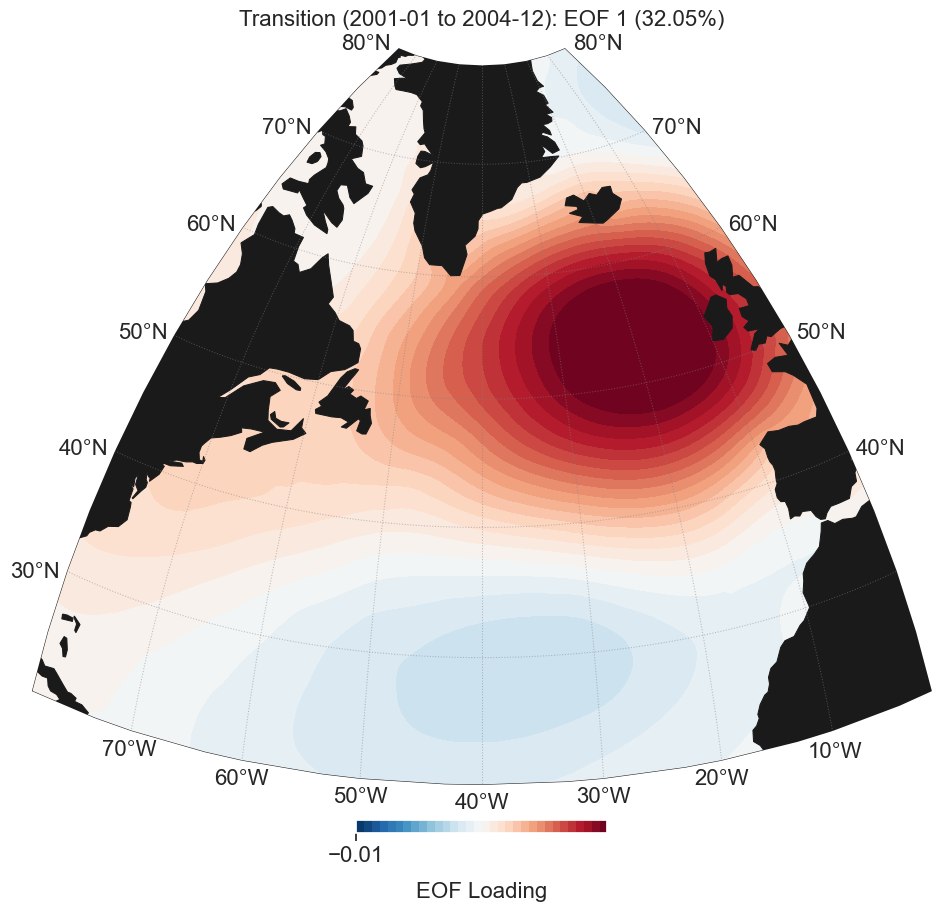

In [242]:
save_name    = 'transition_eof_one'
slp_eof      = eofs_case[0,:,:]
eof_pve      = per_var_case[0]
slp_eof.data[slp_eof.data > 0.01] = 0.01
slp_eof.data[slp_eof.data < -0.01] = -0.01

bbox          = [-80,0,20,80] # Plotting Extent
plot_this_box = [-80,0,0,60]    # Locator box indicating a region
proj          = ccrs.PlateCarree() # Need to add this to most things as "transform=proj"
fig,ax,_      = init_orthomap(1,1,bbox)


# Add Coasts/Continent
ax     = add_coast_grid(ax,bbox,fill_color='k',line_color='k')
levels = np.linspace(-0.01,0.01,33)
# Plot contours
colorplot = ax.contourf(slp_eof.longitude,slp_eof.latitude,slp_eof.data,transform=proj, levels=levels, cmap='RdBu_r', zorder=0)
cbar = plt.colorbar(colorplot, fraction=0.017, pad=0.01, orientation='horizontal',ticks=np.linspace(-0.01, 0.01, 1))
cbar.set_label('EOF Loading', size='16', labelpad=11)
plt.title('Transition (' + str(slp_case.time[0].dt.year.data) + '-' + str(slp_case.time[0].dt.month.data).zfill(2) +  ' to ' + str(slp_case.time[-1].dt.year.data) + '-' + str(slp_case.time[-1].dt.month.data).zfill(2) +'): EOF 1 (' + str('{:.2f}'.format(eof_pve*100)) + '%)', fontsize = 16)

cbar.ax.tick_params(labelsize=16)
plt.savefig(fig_path  + save_name + '.png', format='png', bbox_inches="tight",dpi=100)

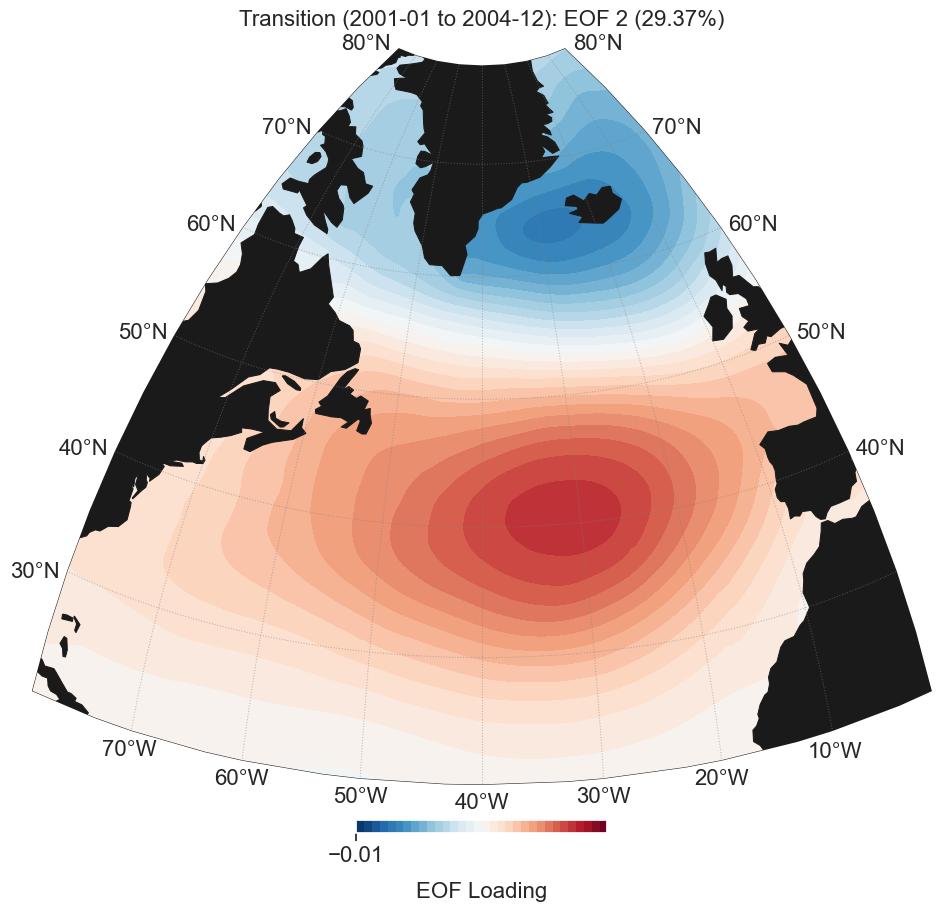

In [243]:
save_name    = 'transition_eof_two'
slp_eof      = eofs_case[1,:,:]
eof_pve      = per_var_case[1]
slp_eof.data[slp_eof.data > 0.01] = 0.01
slp_eof.data[slp_eof.data < -0.01] = -0.01

bbox          = [-80,0,20,80] # Plotting Extent
plot_this_box = [-80,0,0,60]    # Locator box indicating a region
proj          = ccrs.PlateCarree() # Need to add this to most things as "transform=proj"
fig,ax,_      = init_orthomap(1,1,bbox)


# Add Coasts/Continent
ax     = add_coast_grid(ax,bbox,fill_color='k',line_color='k')
levels = np.linspace(-0.01,0.01,33)
# Plot contours
colorplot = ax.contourf(slp_eof.longitude,slp_eof.latitude,slp_eof.data,transform=proj, levels=levels, cmap='RdBu_r', zorder=0)
cbar = plt.colorbar(colorplot, fraction=0.017, pad=0.01, orientation='horizontal',ticks=np.linspace(-0.01, 0.01, 1))
cbar.set_label('EOF Loading', size='16', labelpad=11)
plt.title('Transition (' + str(slp_case.time[0].dt.year.data) + '-' + str(slp_case.time[0].dt.month.data).zfill(2) +  ' to ' + str(slp_case.time[-1].dt.year.data) + '-' + str(slp_case.time[-1].dt.month.data).zfill(2) +'): EOF 2 (' + str('{:.2f}'.format(eof_pve*100)) + '%)', fontsize = 16)

cbar.ax.tick_params(labelsize=16)
plt.savefig(fig_path  + save_name + '.png', format='png', bbox_inches="tight",dpi=100)

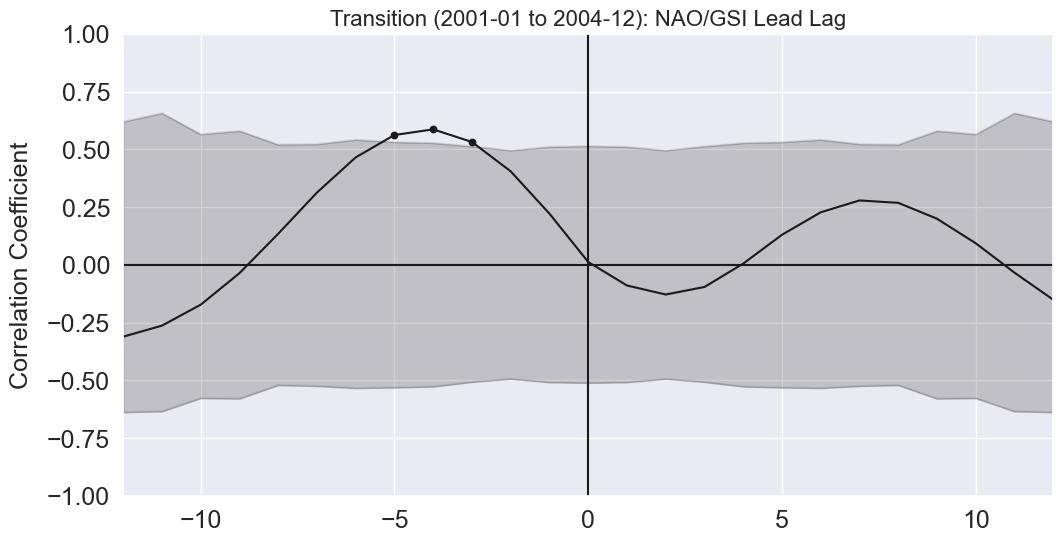

In [244]:
save_name    = 'transition_lead_lag'
ix_temp = []
for l in range(len(corrs_case)):
    if corrs_case[l] > uci[l] or corrs_case[l] < lci[l]:
        ix_temp.append(l)

fig     = plt.figure(figsize=(12, 6))
plt.title('Transition (' + str(slp_case.time[0].dt.year.data) + '-' + str(slp_case.time[0].dt.month.data).zfill(2) +  ' to ' + str(slp_case.time[-1].dt.year.data) + '-' + str(slp_case.time[-1].dt.month.data).zfill(2) +'): NAO/GSI Lead Lag', fontsize = 16)
        
# Bottom Figure is Lead/Lag for that period 
plt.axhline(0,color='k')
plt.axvline(0,color='k')
plt.plot(lags_array,corrs_case,'k')
lci_  = plt.plot(lags_array,lci, color='k',alpha=0.1)
uci_  = plt.plot(lags_array,uci, color='k',alpha=0.1)
ci_sh = plt.fill_between(lags_array,lci,uci,color='k',alpha=0.2)
plt.scatter(lags_array[ix_temp], corrs_case[ix_temp], s=21, color = 'k',edgecolors='k',zorder = 10)
xtix = plt.yticks(fontsize=18)
xtix = plt.xticks(fontsize=18)
ylab = plt.ylabel('Correlation Coefficient', fontsize = 18, labelpad=10)
plt.ylim(-1,1)
plt.xlim(-12,12)
plt.savefig(fig_path  + save_name + '.png', format='png', bbox_inches="tight",dpi=100)

### Now, WSC-NAO Regressions

In [245]:
def linregress_at_point(var_one, var_two):
    if np.all(np.isnan(var_two)):  # Handle missing data
        return np.nan, np.nan, np.nan, np.nan, np.nan
    slope, intercept, r_value, p_value, std_err = linregress(var_one, var_two)
    return slope, intercept, r_value**2, p_value, std_err

In [246]:
def linregress_spatial(var_one, var_two):
    results = xr.apply_ufunc(
        linregress_at_point,
        var_one,    # (time,)
        var_two,    # (time, lat, lon)
        input_core_dims  = [['time'], ['time']],  # Apply along time axis
        output_core_dims = [[], [], [], [], []],  # Scalar outputs per point
        vectorize = True,  # Apply function element-wise
        dask = 'parallelized',  # Enables parallel computation if using Dask
        output_dtypes = [np.float64, np.float64, np.float64, np.float64, np.float64]
    )
    
    slope, intercept, r_squared, p_value, std_err = results
    slope     = xr.DataArray(slope,     dims=('latitude', 'longitude'), coords={'latitude': var_two.latitude, 'longitude': var_two.longitude})
    intercept = xr.DataArray(intercept, dims=('latitude', 'longitude'), coords={'latitude': var_two.latitude, 'longitude': var_two.longitude})
    r_squared = xr.DataArray(r_squared, dims=('latitude', 'longitude'), coords={'latitude': var_two.latitude, 'longitude': var_two.longitude})
    p_value   = xr.DataArray(p_value,   dims=('latitude', 'longitude'), coords={'latitude': var_two.latitude, 'longitude': var_two.longitude})
    std_err   = xr.DataArray(std_err,   dims=('latitude', 'longitude'), coords={'latitude': var_two.latitude, 'longitude': var_two.longitude})
    
    regression_results = xr.Dataset(
        {
            'slope': slope,
            'intercept': intercept,
            'r_squared': r_squared,
            'p_value': p_value,
            'std_err': std_err,
        }
    )
    return regression_results

In [247]:
wsc_ds = xr.open_dataset(data_path + 'climate_fields/wsc.nc')
wsc_ds['longitude'] = wsc_ds.longitude + 360
wsc_ds = rmv_clm(wsc_ds)
wsc_ds = seasonal_detrend(wsc_ds)

In [248]:
nao_case_one = nao_unscaled.sel(time = slice(np.datetime64(str(1996) + '-06-01'),np.datetime64(str(2000) + '-06-01')))
wsc_case_one = wsc_ds.wsc.sel(time = slice(np.datetime64(str(1996) + '-06-01'),np.datetime64(str(2000) + '-06-01')))

In [249]:
nao_transition = nao_unscaled.sel(time = slice(np.datetime64(str(2001) + '-01-01'),np.datetime64(str(2004) + '-12-01')))
wsc_transition = wsc_ds.wsc.sel(time = slice(np.datetime64(str(2001) + '-01-01'),np.datetime64(str(2004) + '-12-01')))

In [250]:
nao_case_two = nao_unscaled.sel(time = slice(np.datetime64(str(2005) + '-06-01'),np.datetime64(str(2009) + '-06-01')))
wsc_case_two = wsc_ds.wsc.sel(time = slice(np.datetime64(str(2005) + '-06-01'),np.datetime64(str(2009) + '-06-01')))

In [251]:
reg_case_one   = linregress_spatial(nao_case_one, wsc_case_one)
reg_transition = linregress_spatial(nao_transition, wsc_transition)
reg_case_two   = linregress_spatial(nao_case_two, wsc_case_two)

In [252]:
alt     = pd.read_csv(data_path + 'gsi/alt_gsi_locs.csv')

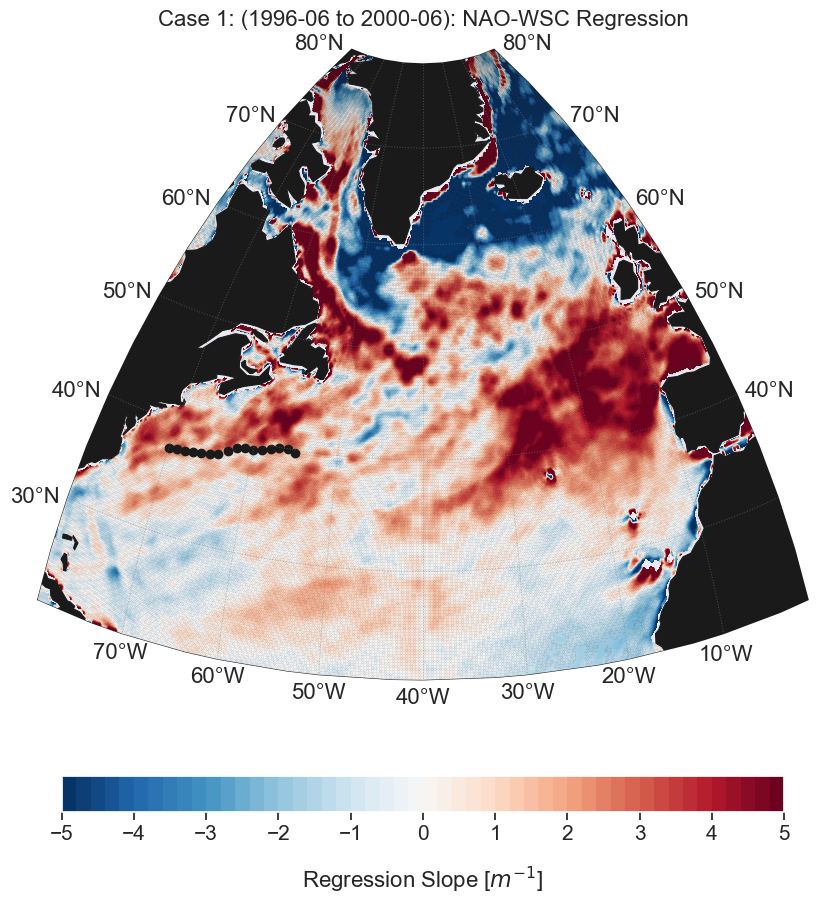

In [253]:
save_name = 'case_one_wsc_nao_reg'
reg_variable = reg_case_one*100
reg_variable.slope.data[reg_variable.slope.data > 5] = 5
reg_variable.slope.data[reg_variable.slope.data < -5] = -5

bbox          = [-80,0,20,80] # Plotting Extent
plot_this_box = [-80,0,0,60]    # Locator box indicating a region
proj          = ccrs.PlateCarree() # Need to add this to most things as "transform=proj"
fig,ax,_      = init_orthomap(1,1,bbox)
# Add Coasts/Continent
ax     = add_coast_grid(ax,bbox,fill_color='k',line_color='k')
levels = np.linspace(-5,5,51)
# Plot contours
colorplot = ax.contourf(reg_variable.longitude,reg_variable.latitude,reg_variable.slope,transform=proj, levels=levels, cmap='RdBu_r', zorder=0)
cbar = plt.colorbar(colorplot, fraction=0.057, pad=0.1, orientation='horizontal',ticks=np.linspace(-5, 5, 11))
cbar.set_label('Regression Slope [$m^{-1}$]', size='16', labelpad=15)
cbar.ax.tick_params(labelsize=15)
xorg = reg_variable.longitude.data
yorg = reg_variable.latitude.data
nlon = len(xorg)
nlat = len(yorg)
xdata = np.reshape(np.tile(xorg, nlat), reg_variable.slope.shape)
ydata = np.reshape(np.repeat(yorg, nlon), reg_variable.slope.shape)
xpoints = xdata[reg_variable.p_value > 0.05]
ypoints = ydata[reg_variable.p_value > 0.05]
ax.scatter(xpoints, ypoints, s=0.2, c='k', marker='.', alpha=0.3,transform=proj)

plt.scatter(alt['longitude'], alt['latitude'], color='k', transform = proj)
plt.title('Case 1: (' + str(nao_case_one.time[0].dt.year.data) + '-' + str(nao_case_one.time[0].dt.month.data).zfill(2) +  ' to ' + str(nao_case_one.time[-1].dt.year.data) + '-' + str(nao_case_one.time[-1].dt.month.data).zfill(2) +'): NAO-WSC Regression', fontsize = 16)

plt.savefig(fig_path  + save_name + '.png', format='png', bbox_inches="tight",dpi=500)

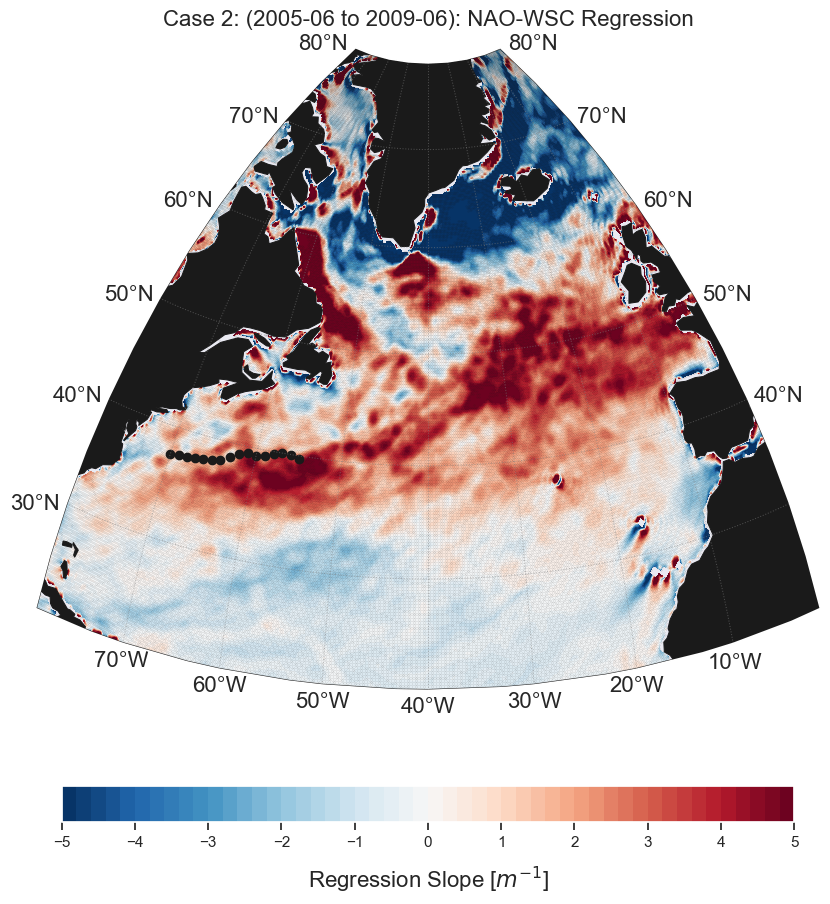

In [254]:
save_name = 'case_two_wsc_nao_reg'
reg_variable = reg_case_two*100
reg_variable.slope.data[reg_variable.slope.data > 5] = 5
reg_variable.slope.data[reg_variable.slope.data < -5] = -5

bbox          = [-80,0,20,80] # Plotting Extent
plot_this_box = [-80,0,0,60]    # Locator box indicating a region
proj          = ccrs.PlateCarree() # Need to add this to most things as "transform=proj"
fig,ax,_      = init_orthomap(1,1,bbox)
# Add Coasts/Continent
ax     = add_coast_grid(ax,bbox,fill_color='k',line_color='k')
levels = np.linspace(-5,5,51)
# Plot contours
colorplot = ax.contourf(reg_variable.longitude,reg_variable.latitude,reg_variable.slope,transform=proj, levels=levels, cmap='RdBu_r', zorder=0)
cbar = plt.colorbar(colorplot, fraction=0.057, pad=0.1, orientation='horizontal',ticks=np.linspace(-5, 5, 11))
cbar.set_label('Regression Slope [$m^{-1}$]', size='16', labelpad=11)
cbar.ax.tick_params(labelsize=11)
xorg = reg_variable.longitude.data
yorg = reg_variable.latitude.data
nlon = len(xorg)
nlat = len(yorg)
xdata = np.reshape(np.tile(xorg, nlat), reg_variable.slope.shape)
ydata = np.reshape(np.repeat(yorg, nlon), reg_variable.slope.shape)
xpoints = xdata[reg_variable.p_value > 0.01]
ypoints = ydata[reg_variable.p_value > 0.01]
ax.scatter(xpoints, ypoints, s=0.2, c='k', marker='.', alpha=0.3,transform=proj)

plt.scatter(alt['longitude'], alt['latitude'], color='k', transform = proj)
plt.title('Case 2: (' + str(nao_case_two.time[0].dt.year.data) + '-' + str(nao_case_two.time[0].dt.month.data).zfill(2) +  ' to ' + str(nao_case_two.time[-1].dt.year.data) + '-' + str(nao_case_two.time[-1].dt.month.data).zfill(2) +'): NAO-WSC Regression', fontsize = 16)

plt.savefig(fig_path  + save_name + '.png', format='png', bbox_inches="tight",dpi=100)

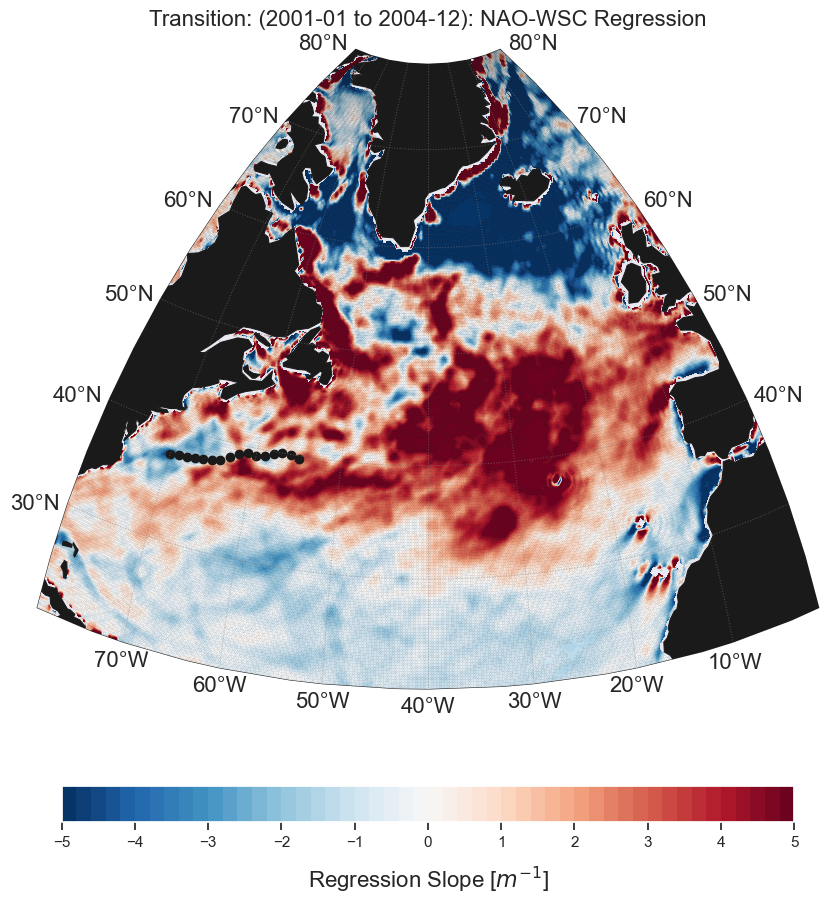

In [255]:
save_name = 'transition_wsc_nao_reg'
reg_variable = reg_transition*100
reg_variable.slope.data[reg_variable.slope.data > 5] = 5
reg_variable.slope.data[reg_variable.slope.data < -5] = -5

bbox          = [-80,0,20,80] # Plotting Extent
plot_this_box = [-80,0,0,60]    # Locator box indicating a region
proj          = ccrs.PlateCarree() # Need to add this to most things as "transform=proj"
fig,ax,_      = init_orthomap(1,1,bbox)
# Add Coasts/Continent
ax     = add_coast_grid(ax,bbox,fill_color='k',line_color='k')
levels = np.linspace(-5,5,51)
# Plot contours
colorplot = ax.contourf(reg_variable.longitude,reg_variable.latitude,reg_variable.slope,transform=proj, levels=levels, cmap='RdBu_r', zorder=0)
cbar = plt.colorbar(colorplot, fraction=0.057, pad=0.1, orientation='horizontal',ticks=np.linspace(-5, 5, 11))
cbar.set_label('Regression Slope [$m^{-1}$]', size='16', labelpad=11)
cbar.ax.tick_params(labelsize=11)
xorg = reg_variable.longitude.data
yorg = reg_variable.latitude.data
nlon = len(xorg)
nlat = len(yorg)
xdata = np.reshape(np.tile(xorg, nlat), reg_variable.slope.shape)
ydata = np.reshape(np.repeat(yorg, nlon), reg_variable.slope.shape)
xpoints = xdata[reg_variable.p_value > 0.01]
ypoints = ydata[reg_variable.p_value > 0.01]
ax.scatter(xpoints, ypoints, s=0.2, c='k', marker='.', alpha=0.3,transform=proj)

plt.scatter(alt['longitude'], alt['latitude'], color='k', transform = proj)
plt.title('Transition: (' + str(nao_transition.time[0].dt.year.data) + '-' + str(nao_transition.time[0].dt.month.data).zfill(2) +  ' to ' + str(nao_transition.time[-1].dt.year.data) + '-' + str(nao_transition.time[-1].dt.month.data).zfill(2) +'): NAO-WSC Regression', fontsize = 16)

plt.savefig(fig_path  + save_name + '.png', format='png', bbox_inches="tight",dpi=100)